In [5]:
import pandas as pd

train_path = r"E:\CodSoft_datasets_for_tasks\credit_card\fraudTrain.csv"
test_path = r"E:\CodSoft_datasets_for_tasks\credit_card\fraudTest.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(train_df.shape)
print(test_df.shape)

train_df.head()

(1296675, 23)
(555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
print(train_df.isnull().sum())

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [7]:
drop_cols = [
    'Unnamed: 0',
    'trans_date_trans_time',
    'cc_num',
    'first',
    'last',
    'street',
    'trans_num',
    'dob'
]

train_df = train_df.drop(columns=drop_cols)
test_df = test_df.drop(columns=drop_cols)

In [8]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = train_df.select_dtypes(include='object').columns

for col in categorical_cols:

    le = LabelEncoder()

    combined = pd.concat([
        train_df[col].astype(str),
        test_df[col].astype(str)
    ])

    le.fit(combined)

    train_df[col] = le.transform(train_df[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

In [9]:
X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

In [10]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le_city = LabelEncoder()

combined_city = pd.concat([
    X_train['city'].astype(str),
    X_test['city'].astype(str)
])

le_city.fit(combined_city)

X_train['city'] = le_city.transform(X_train['city'].astype(str))
X_test['city'] = le_city.transform(X_test['city'].astype(str))

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [12]:
print(X_train.dtypes.value_counts())
print(X_test.dtypes.value_counts())

int32      6
float64    5
int64      3
Name: count, dtype: int64
int32      6
float64    5
int64      3
Name: count, dtype: int64


In [13]:
for col in X_test.columns:
    if X_test[col].dtype == 'object':
        print(col)

In [15]:
predictions = model.predict(X_test)

In [16]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:\n")

print(classification_report(y_test, predictions))

Accuracy: 0.9970812586936924

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.73      0.39      0.51      2145

    accuracy                           1.00    555719
   macro avg       0.86      0.70      0.75    555719
weighted avg       1.00      1.00      1.00    555719



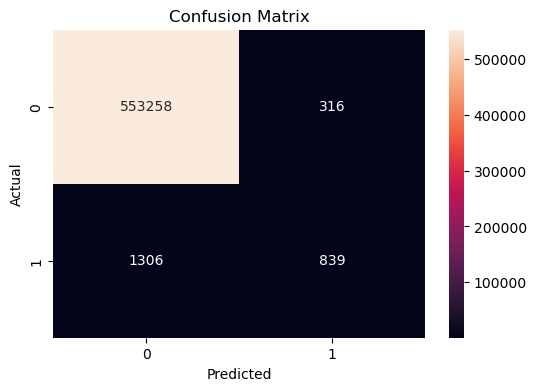

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

       Feature  Importance
2          amt    0.415756
1     category    0.165296
11   unix_time    0.066224
12   merch_lat    0.051521
13  merch_long    0.051361
0     merchant    0.042431
9     city_pop    0.037810
10         job    0.030668
4         city    0.030526
7          lat    0.028639
